In [ ]:
# Lib Install and Import
# !pip install sentence-transformers scikit-learn pandas numpy matplotlib pinecone
import time
import nltk
import numpy as np
import pandas as pd
from pinecone import Pinecone, ServerlessSpec
from nltk.corpus import wordnet
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer


# Load HuggingFace embedding model and Pinecone
nltk.download('wordnet')
pc = Pinecone(api_key="paste-api-key")
index_name = "nexora-vibe-matcher-by-kratu-gautam"

# Delete if exists
if pc.has_index(index_name):
    pc.delete_index(index_name)

# Create serverless index
pc.create_index(
    name=index_name,
    dimension=768,
    metric="cosine",
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)
index =  pc.Index(index_name)
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [16]:
print(pc.list_indexes())
#pc.delete_index("nexora-vibe-matcher-by-kratu-gautam")

[]


In [11]:
items = [
    {"name": "Boho Breeze Dress", "desc": "Flowy maxi in earthy tones, tassels and airy silhouette for festival vibes.", "vibes": ["boho", "earthy", "festival"]},
    {"name": "Urban Sprint Sneakers", "desc": "Chunky sole, reflective accents, built for city runs and late-night street style.", "vibes": ["urban", "sporty", "energetic"]},
    {"name": "Minimalist Silk Shirt", "desc": "Clean lines, crisp collar, subtle sheen—timeless piece for modern minimal wardrobes.", "vibes": ["minimal", "chic", "formal"]},
    {"name": "Cozy Knit Cardigan", "desc": "Warm, oversized knit with soft texture—perfect for layered comfort on cool evenings.", "vibes": ["cozy", "warm", "casual"]},
    {"name": "Street Edge Jacket", "desc": "Matte black bomber with utility pockets and neon trim for bold urban attitude.", "vibes": ["urban", "bold", "streetwear"]},
    {"name": "Retro Pop Tee", "desc": "Color-blocked graphic tee with vintage print—playful throwback energy.", "vibes": ["retro", "playful", "casual"]},
    {"name": "Sustainable Linen Pants", "desc": "Breathable linen with tapered fit—eco-conscious comfort, refined and airy.", "vibes": ["eco", "refined", "minimal"]},
    {"name": "Monochrome Slip Dress", "desc": "Sleek, black slip with minimalist straps—elevated simplicity for night outs.", "vibes": ["minimal", "chic", "night"]},
    {"name": "Trail Hybrid Boots", "desc": "Rugged outsole with city-ready upper—outdoor performance meets urban utility.", "vibes": ["outdoor", "urban", "utility"]},
    {"name": "Pastel Lounge Set", "desc": "Soft pastel co-ord with relaxed fit—soothing aesthetic for slow Sundays.", "vibes": ["pastel", "cozy", "soothing"]},
]

df = pd.DataFrame(items)
df


,name,desc,vibes
0,Boho Breeze Dress,"Flowy maxi in earthy tones, tassels and airy s...","[boho, earthy, festival]"
1,Urban Sprint Sneakers,"Chunky sole, reflective accents, built for cit...","[urban, sporty, energetic]"
2,Minimalist Silk Shirt,"Clean lines, crisp collar, subtle sheen—timele...","[minimal, chic, formal]"
3,Cozy Knit Cardigan,"Warm, oversized knit with soft texture—perfect...","[cozy, warm, casual]"
4,Street Edge Jacket,Matte black bomber with utility pockets and ne...,"[urban, bold, streetwear]"
5,Retro Pop Tee,Color-blocked graphic tee with vintage print—p...,"[retro, playful, casual]"
6,Sustainable Linen Pants,Breathable linen with tapered fit—eco-consciou...,"[eco, refined, minimal]"
7,Monochrome Slip Dress,"Sleek, black slip with minimalist straps—eleva...","[minimal, chic, night]"
8,Trail Hybrid Boots,Rugged outsole with city-ready upper—outdoor p...,"[outdoor, urban, utility]"
9,Pastel Lounge Set,Soft pastel co-ord with relaxed fit—soothing a...,"[pastel, cozy, soothing]"


In [26]:
# Embed all descriptions
start = time.perf_counter()
embed_latency = time.perf_counter() - start
df["text"] = df["desc"] + " " + df["vibes"].apply(lambda v: " ".join(v))
df["embedding"] = list(model.encode(df["text"], convert_to_numpy=True))

# Upsert product vectors for pinecone
for i, row in df.iterrows():
    vec = model.encode(row["desc"] + " " + " ".join(row["vibes"]))
    index.upsert([(str(i), vec.tolist(), {"name": row["name"], "tags": row["vibes"]})])

# Utility: query embedding + cosine sim
# pinecone version
def query_pinecone(q_vec, top_k=3):
  q_vec = model.encode(q_vec)
  results = index.query(vector=q_vec.tolist(), top_k=top_k, include_metadata=True)
  return results

print(query_pinecone("cozy knit cardigan warm casual streetwear"))
print("\n\n\n")

# huggingface version
def search(query: str, top_k: int = 3, threshold: float = 0.0):
    q_vec = model.encode([query], convert_to_numpy=True)[0]
    X = np.stack(df["embedding"].to_list())
    sims = cosine_similarity(q_vec.reshape(1, -1), X).ravel()
    order = sims.argsort()[::-1]
    ranked = []
    for idx in order[:top_k]:
        score = float(sims[idx])
        if score >= threshold:
            ranked.append({
                "name": df.loc[idx, "name"],
                "score": round(score, 4),
                "desc": df.loc[idx, "desc"],
                "vibes": df.loc[idx, "vibes"],
            })
    if not ranked:
        ranked.append({
            "name": "No strong match",
            "score": 0.0,
            "desc": "Try refining your vibe (e.g., 'bold urban night' or 'soft cozy pastel').",
            "vibes": [],
        })
    return ranked
search("cozy knit cardigan warm casual streetwear")

{'matches': [{'id': '3',
              'metadata': {'name': 'Cozy Knit Cardigan',
                           'tags': ['cozy', 'warm', 'casual']},
              'score': 0.728127539,
              'values': []},
             {'id': '4',
              'metadata': {'name': 'Street Edge Jacket',
                           'tags': ['urban', 'bold', 'streetwear']},
              'score': 0.55071646,
              'values': []},
             {'id': '6',
              'metadata': {'name': 'Sustainable Linen Pants',
                           'tags': ['eco', 'refined', 'minimal']},
              'score': 0.51407057,
              'values': []}],
 'namespace': '',
 'usage': {'read_units': 1}}






[{'name': 'Cozy Knit Cardigan',
  'score': 0.7279,
  'desc': 'Warm, oversized knit with soft texture—perfect for layered comfort on cool evenings.',
  'vibes': ['cozy', 'warm', 'casual']},
 {'name': 'Street Edge Jacket',
  'score': 0.5507,
  'desc': 'Matte black bomber with utility pockets and neon trim for bold urban attitude.',
  'vibes': ['urban', 'bold', 'streetwear']},
 {'name': 'Sustainable Linen Pants',
  'score': 0.5141,
  'desc': 'Breathable linen with tapered fit—eco-conscious comfort, refined and airy.',
  'vibes': ['eco', 'refined', 'minimal']}]

In [29]:
def show_results(query: str, top_k: int = 3, threshold: float = 0.2):
    t0 = time.perf_counter()
    results = search(query, top_k=top_k, threshold=threshold)
    latency = time.perf_counter() - t0
    print(f"Query: {query}")
    print(f"Latency: {latency*1000:.2f} ms")
    for i, r in enumerate(results, 1):
        print(f"{i}. {r['name']} (score={r['score']})")
        print(f"   {r['desc']}")
        print(f"   tags: {', '.join(r['vibes'])}")
    return results, latency
show_results("soft cozy pastel aesthetic", top_k=5)
print("\n\n\n")
query_pinecone("soft cozy pastel aesthetic", top_k=5)

Query: soft cozy pastel aesthetic
Latency: 90.84 ms
1. Pastel Lounge Set (score=0.7995)
   Soft pastel co-ord with relaxed fit—soothing aesthetic for slow Sundays.
   tags: pastel, cozy, soothing
2. Cozy Knit Cardigan (score=0.5005)
   Warm, oversized knit with soft texture—perfect for layered comfort on cool evenings.
   tags: cozy, warm, casual
3. Sustainable Linen Pants (score=0.4499)
   Breathable linen with tapered fit—eco-conscious comfort, refined and airy.
   tags: eco, refined, minimal
4. Retro Pop Tee (score=0.3872)
   Color-blocked graphic tee with vintage print—playful throwback energy.
   tags: retro, playful, casual
5. Minimalist Silk Shirt (score=0.3842)
   Clean lines, crisp collar, subtle sheen—timeless piece for modern minimal wardrobes.
   tags: minimal, chic, formal






{'matches': [{'id': '9',
              'metadata': {'name': 'Pastel Lounge Set',
                           'tags': ['pastel', 'cozy', 'soothing']},
              'score': 0.79957968,
              'values': []},
             {'id': '3',
              'metadata': {'name': 'Cozy Knit Cardigan',
                           'tags': ['cozy', 'warm', 'casual']},
              'score': 0.500434,
              'values': []},
             {'id': '6',
              'metadata': {'name': 'Sustainable Linen Pants',
                           'tags': ['eco', 'refined', 'minimal']},
              'score': 0.450111419,
              'values': []},
             {'id': '5',
              'metadata': {'name': 'Retro Pop Tee',
                           'tags': ['retro', 'playful', 'casual']},
              'score': 0.387435913,
              'values': []},
             {'id': '2',
              'metadata': {'name': 'Minimalist Silk Shirt',
                           'tags': ['minimal', 'chic', 'formal']}

                                               query  best_score   good  \
0  cozy knit cardigan cozy knit Cardigan cardigan...      0.6657  False   
1  soft cozy pastel aesthetic cozy pastel soft ae...      0.7858   True   
2                 slip dress, chic night outfit slip      0.7096   True   

   latency_ms  
0      158.63  
1      143.27  
2      124.95  


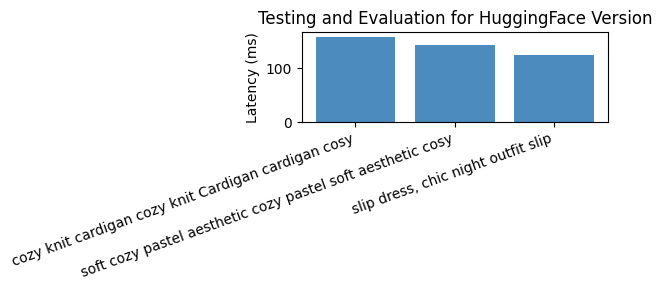

In [39]:
# Testing and Evaluation for HuggingFace Version

queries = [
    "cozy knit cardigan warm casual streetwear", # expect sneakers, jacket, streetwear
    "soft cozy pastel aesthetic cozy pastel soft aesthetic cosy",   # expect cardigan, lounge set
    "slip dress, chic night outfit slip", # expect slip dress, silk shirt
]

logs = []
for q in queries:
    t0 = time.perf_counter()
    # Encode query
    q_vec = model.encode([q], convert_to_numpy=True)[0]
    # Extract best match
    sims = cosine_similarity(q_vec.reshape(1, -1), np.stack(df["embedding"].to_list())).ravel()
    order = sims.argsort()[::-1]
    best_score = float(sims[order[0]])
    good = best_score > 0.7
    latency = (time.perf_counter() - t0) * 1000
    logs.append({"query": q, "best_score": round(best_score, 4), "good": good, "latency_ms": round(latency, 2)})

eval_df = pd.DataFrame(logs)
print(eval_df)

# Plot latency
plt.figure(figsize=(6,3))
plt.bar(eval_df["query"], eval_df["latency_ms"], color="#4B8BBE")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=20, ha="right")
plt.title("Testing and Evaluation for HuggingFace Version")
plt.tight_layout()
plt.show()


                                               query  best_score  good  \
0          cozy knit cardigan warm casual streetwear      0.7281  True   
1  soft cozy pastel aesthetic cozy pastel soft ae...      0.7855  True   
2                 slip dress, chic night outfit slip      0.7102  True   

   latency_ms  
0      518.83  
1      268.92  
2      190.95  


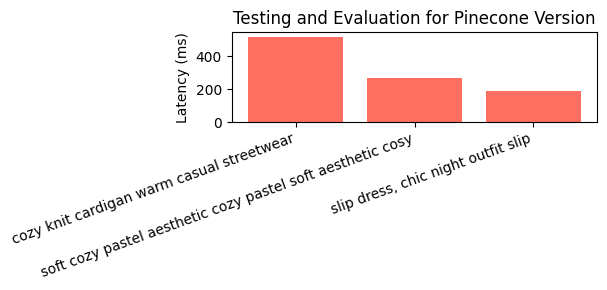

In [43]:
# Testing and Evaluation for Pinecone Version

queries = [
    "cozy knit cardigan warm casual streetwear",  # expect sneakers, jacket, streetwear
    "soft cozy pastel aesthetic cozy pastel soft aesthetic cosy",  # expect cardigan, lounge set
    "slip dress, chic night outfit slip",  # expect slip dress, silk shirt
]

logs = []
for q in queries:
    t0 = time.perf_counter()
    # Encode query
    q_vec = model.encode([q], convert_to_numpy=True)[0]
    # Query Pinecone
    results = index.query(vector=q_vec.tolist(), top_k=3, include_metadata=True)
    # Extract best match
    matches = results["matches"]
    best_score = matches[0]["score"] if matches else 0.0
    good = best_score > 0.7
    latency = (time.perf_counter() - t0) * 1000
    logs.append({
        "query": q,
        "best_score": round(best_score, 4),
        "good": good,
        "latency_ms": round(latency, 2)
    })

# Convert to DataFrame
eval_df_pinecone = pd.DataFrame(logs)
print(eval_df_pinecone)

# Plot latency
plt.figure(figsize=(6,3))
plt.bar(eval_df_pinecone["query"], eval_df_pinecone["latency_ms"], color="#FF6F61")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=20, ha="right")
plt.title("Testing and Evaluation for Pinecone Version")
plt.tight_layout()
plt.show()


In [41]:
# If your query is too short for model for understand

def expand_query(query):
    tokens = query.split()
    expanded = []
    for t in tokens:
        syns = [s.lemma_names()[0] for s in wordnet.synsets(t)[:2]]  # top 2 synonyms
        expanded.extend(syns)
    return query + " " + " ".join(set(expanded))

q = "cozy knit cardigan"
print(expand_query(q))
# → the output will be expanded form of query.

cozy knit cardigan warm casual streetwear


In [44]:
#!pip freeze > requirements.txt